## COMP4030 : High-Spender Prediction 

This notebook ensures fair model comparison (with scaling where needed) and uses F1-score to select the best model.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
import shap

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


### Data Loading 

In [2]:

# user to adjust based on actual file locations
transactions = pd.read_csv('transaction_data.csv')
products = pd.read_csv('product.csv')
hh_demographics = pd.read_csv('hh_demographic.csv')
causal_data = pd.read_csv('causal_data.csv')

# Standardize column names
for df in [transactions, products, hh_demographics, causal_data]:
    df.columns = df.columns.str.lower()

# Merge and optimize
transactions = transactions.merge(products, on='product_id', how='left')
transactions = transactions.merge(hh_demographics, on='household_key', how='left')

transactions = transactions.astype({
    'day': 'int16',
    'quantity': 'int8',
    'week_no': 'int8',
    'trans_time': 'int16',
    'sales_value': 'float32',
    'retail_disc': 'float32',
    'coupon_disc': 'float32',
    'coupon_match_disc': 'float32'
})

causal_subset_keys = transactions[['store_id', 'week_no']].drop_duplicates()
causal_data_filtered = causal_data.merge(causal_subset_keys, on=['store_id', 'week_no'], how='inner')
transactions = transactions.merge(causal_data_filtered, on=['product_id', 'store_id', 'week_no'], how='left')


### Feature Engineering

In [3]:

transactions['high_spender'] = (transactions['sales_value'] > transactions['sales_value'].median()).astype(int)

features = ['quantity', 'coupon_match_disc', 'retail_disc', 'age_desc', 'marital_status_code', 'income_desc', 'household_size_desc']
X = pd.get_dummies(transactions[features])
y = transactions['high_spender']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### Model Training, Scaling, and F1-Score Based Selection

In [4]:

# Define models with appropriate scaling
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()), 
        ('clf', LogisticRegression(max_iter=1000))
    ]),
    
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'Random Forest': RandomForestClassifier(n_estimators=100)
}

model_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    model_scores[name] = {
        'model': model,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    }
    
    print(f"Model: {name}")
    print(f" Accuracy: {acc:.4f}")
    print(f" Precision: {prec:.4f}")
    print(f" Recall: {rec:.4f}")
    print(f" F1-Score: {f1:.4f}")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))
    print("-" * 50)

# Select the best model
best_model_name = max(model_scores, key=lambda k: model_scores[k]['f1_score'])
best_model = model_scores[best_model_name]['model']
print(f"Best model based on F1-Score: {best_model_name}")


Model: Logistic Regression
 Accuracy: 0.5616
 Precision: 0.5848
 Recall: 0.4021
 F1-Score: 0.4765
[[282059 110332]
 [231159 155427]]
              precision    recall  f1-score   support

           0       0.55      0.72      0.62    392391
           1       0.58      0.40      0.48    386586

    accuracy                           0.56    778977
   macro avg       0.57      0.56      0.55    778977
weighted avg       0.57      0.56      0.55    778977

--------------------------------------------------


C:\Users\lenovo\AppData\Roaming\Python\Python39\site-packages\xgboost\core.py:158: UserWarning: [00:48:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model: XGBoost
 Accuracy: 0.6519
 Precision: 0.6165
 Recall: 0.7899
 F1-Score: 0.6925
[[202467 189924]
 [ 81233 305353]]
              precision    recall  f1-score   support

           0       0.71      0.52      0.60    392391
           1       0.62      0.79      0.69    386586

    accuracy                           0.65    778977
   macro avg       0.67      0.65      0.65    778977
weighted avg       0.67      0.65      0.65    778977

--------------------------------------------------
Model: Random Forest
 Accuracy: 0.6604
 Precision: 0.6264
 Recall: 0.7822
 F1-Score: 0.6957
[[212060 180331]
 [ 84183 302403]]
              precision    recall  f1-score   support

           0       0.72      0.54      0.62    392391
           1       0.63      0.78      0.70    386586

    accuracy                           0.66    778977
   macro avg       0.67      0.66      0.66    778977
weighted avg       0.67      0.66      0.66    778977

-----------------------------------------------

### Confusion Matrix and ROC Curve

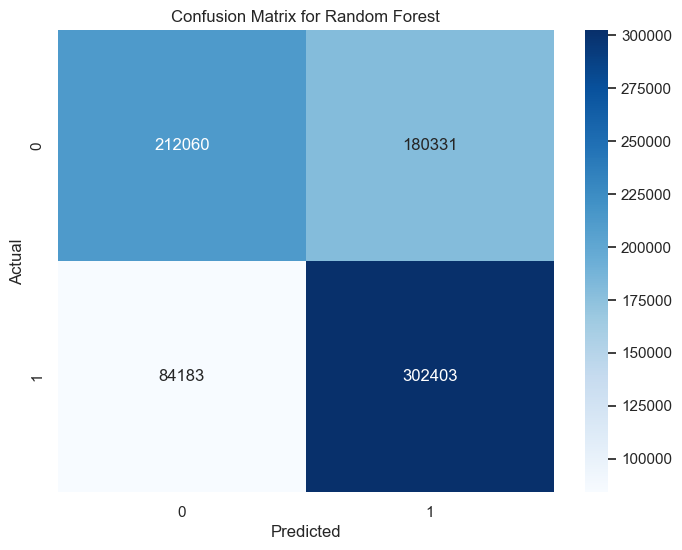

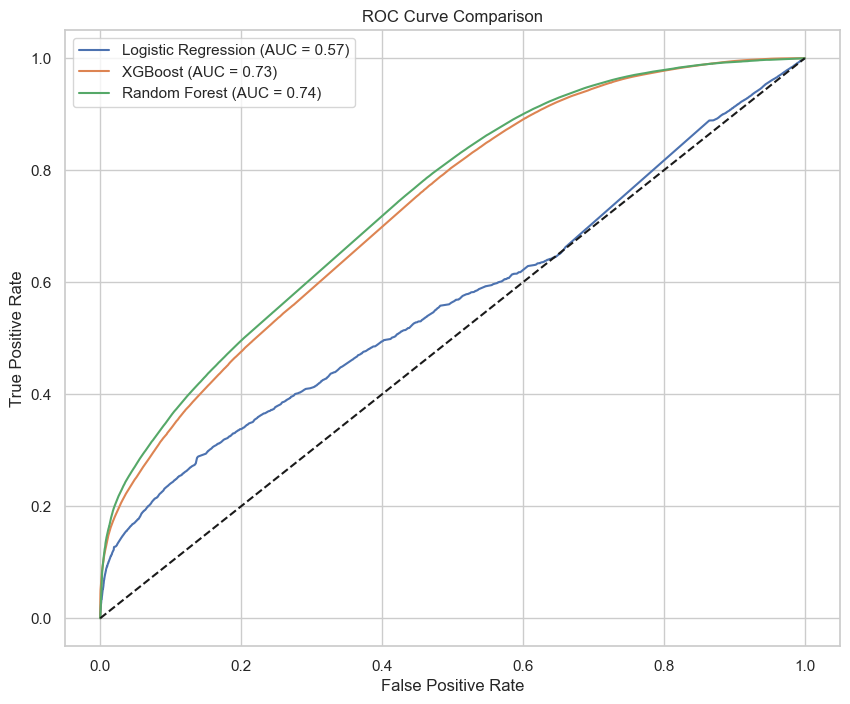

In [5]:

# Confusion Matrix
plt.figure(figsize=(8,6))
y_pred_best = best_model.predict(X_test)
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
plt.figure(figsize=(10,8))
for name, record in model_scores.items():
    model = record['model']
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()
